In [2]:
import os
import pathlib

import warnings
warnings.filterwarnings("ignore")

import FunctionLib as FL

import numpy as np
import pandas as pd
from scipy.signal import savgol_filter

from collections import defaultdict

import matplotlib as mpl
import matplotlib.pyplot as plt
config = {
    "font.size": 18,
    "font.family": "serif",
    "figure.figsize": (25, 14),

    "axes.titlesize": 28,
    "axes.labelsize": 24,
    "legend.fontsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,

    "axes.linewidth": 2,
    "axes.edgecolor": "black",

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,

    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.minor.width": 2,
    "ytick.minor.width": 2,

    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
}
mpl.rcParams.update(config)

import astropy.units as u
import astropy

import corner

DJAv4Catalog = FL.Spectrum_Catalog()
DJAv4Catalog.load_from_pkl(("./DJAV4.2Catalog.pkl"))

print("="*50)
print(f"Total {(DJAv4Catalog.sample_num())} sample objectss loaded.")
print("="*50)

ModuleNotFoundError: No module named 'corner'

In [3]:
dn_index_conditions = np.array([[0, 0.5],[0.5,0.65], [0.65, 0.8], [0.8, 2]])
def dn_condition_func(dn_index):
    for i, (low, high) in enumerate(dn_index_conditions):
        if low < dn_index <= high:
            return i
    return -1

analyst_list = []
for dn_idx in range(len(dn_index_conditions)):
    condition_name = f"DN_Index_{dn_index_conditions[dn_idx][0]:.2f}_to_{dn_index_conditions[dn_idx][1]:.2f}"
    analyst = FL.DustAttenuationAnalyst(DJAv4Catalog)

    surveyid_subid_list = []

    for surveyid_subid, entry in DJAv4Catalog.catalog_iterator():
        if not entry['sample_flag']:
            continue

        # 获取 Flux Ratio
        try:
            measurements = entry['dust_curve_parameters']['Corrected_Flux_Density_Measurements']
            dn_index = measurements['red_flux_density'] / measurements['blue_flux_density']
        except KeyError:
            continue

        # 检查是否属于当前的 Flux Ratio Bin
        if dn_condition_func(dn_index) != dn_idx:
            continue
        surveyid_subid_list.append(surveyid_subid)

    print(f"Processing Condition: {condition_name}, Total Samples: {len(surveyid_subid_list)}")

    # 3. 载入目标 ID 列表
    analyst.load_and_group_objects(surveyid_subid_list)
    analyst.compute_average_spectra()
    analyst.compute_smooth_reference(window_len=101, poly_order=3)

    analyst.compute_attenuation_curves(mode='smoothed')
    if analyst.effective_curve_err is not None:
        print("Error propagation successful. Ready for MCMC.")
    else:
        print("Warning: Error array is empty.")

    analyst.run_mcmc_fitting(nwalkers=32, nsteps=3000, poly_order=3)

# 绘制 MCMC 拟合结果 (带 95% 误差带的蝴蝶结图)

    analyst.plot_mcmc_results(plot_samples=True, n_samples=300)

    if hasattr(analyst, 'mcmc_samples'):
        flat_samples = analyst.mcmc_samples
        labels = ["c3", "c2", "c1", "c0"] # 对应三次多项式系数
        fig = corner.corner(
            flat_samples,
            labels=labels,
            show_titles=True,
            title_fmt=".2f"
        )
        plt.show()

    analyst.derive_k_curve_parameters(intercept_val=-0.89877)

    analyst.plot_derived_k_curve()

fig, ax = plt.subplots()
if_ref=True
colors_list = plt.cm.viridis(np.linspace(0,1,len(analyst_list)))
for analyst in analyst_list:

    dn_index_range = dn_index_conditions[analyst_list.index(analyst)]
    condition_name = f"Dn {dn_index_range[0]:.2f}-{dn_index_range[1]:.2f}"

    analyst.plot_reddening_curve_comparison(
    if_show=False,
    if_input=True, fig=fig, ax=ax,
    curve_color=colors_list[analyst_list.index(analyst)],
    curve_label=condition_name,
    draw_background=if_ref,  # 第一次绘制，需要参考线,
    plot_mcmc_samples=True,  # 开启绘制样本线
    n_samples=1000
)
    if_ref=False  # 之后不需要参考线

plt.show()

Processing Condition: DN_Index_0.00_to_0.50, Total Samples: 352
Categorizing 352 objects...
Group 0: N=34, Mean BD=0.000 +/- 0.003
Group 1: N=46, Mean BD=0.059 +/- 0.004
Group 2: N=39, Mean BD=0.151 +/- 0.005
Group 3: N=34, Mean BD=0.240 +/- 0.005
Group 4: N=12, Mean BD=0.381 +/- 0.012
Group 5: N=9, Mean BD=0.517 +/- 0.014
Group 6: N=14, Mean BD=0.713 +/- 0.016

Computing average spectra...
Failed to load spectrum for entry jades-gdn2-v4_1181_1948: The file /home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_prism-clear_1181_1948.spec.fits does not exist.
Failed to load spectrum for entry rubies-egs53-v4_4233_45472: The file /home/xingyaocai/DJAv4.2/rubies-egs53-v4/rubies-egs53-v4_prism-clear_4233_45472.spec.fits does not exist.
Failed to load spectrum for entry gds-deep-v4_1210_9903: The file /home/xingyaocai/DJAv4.2/gds-deep-v4/gds-deep-v4_prism-clear_1210_9903.spec.fits does not exist.
Failed to load spectrum for entry gds-deep-v4_1210_13854: The file /home/xingyaocai/DJAv4.2/gds-d

ValueError: Group 0 (Reference) is missing.

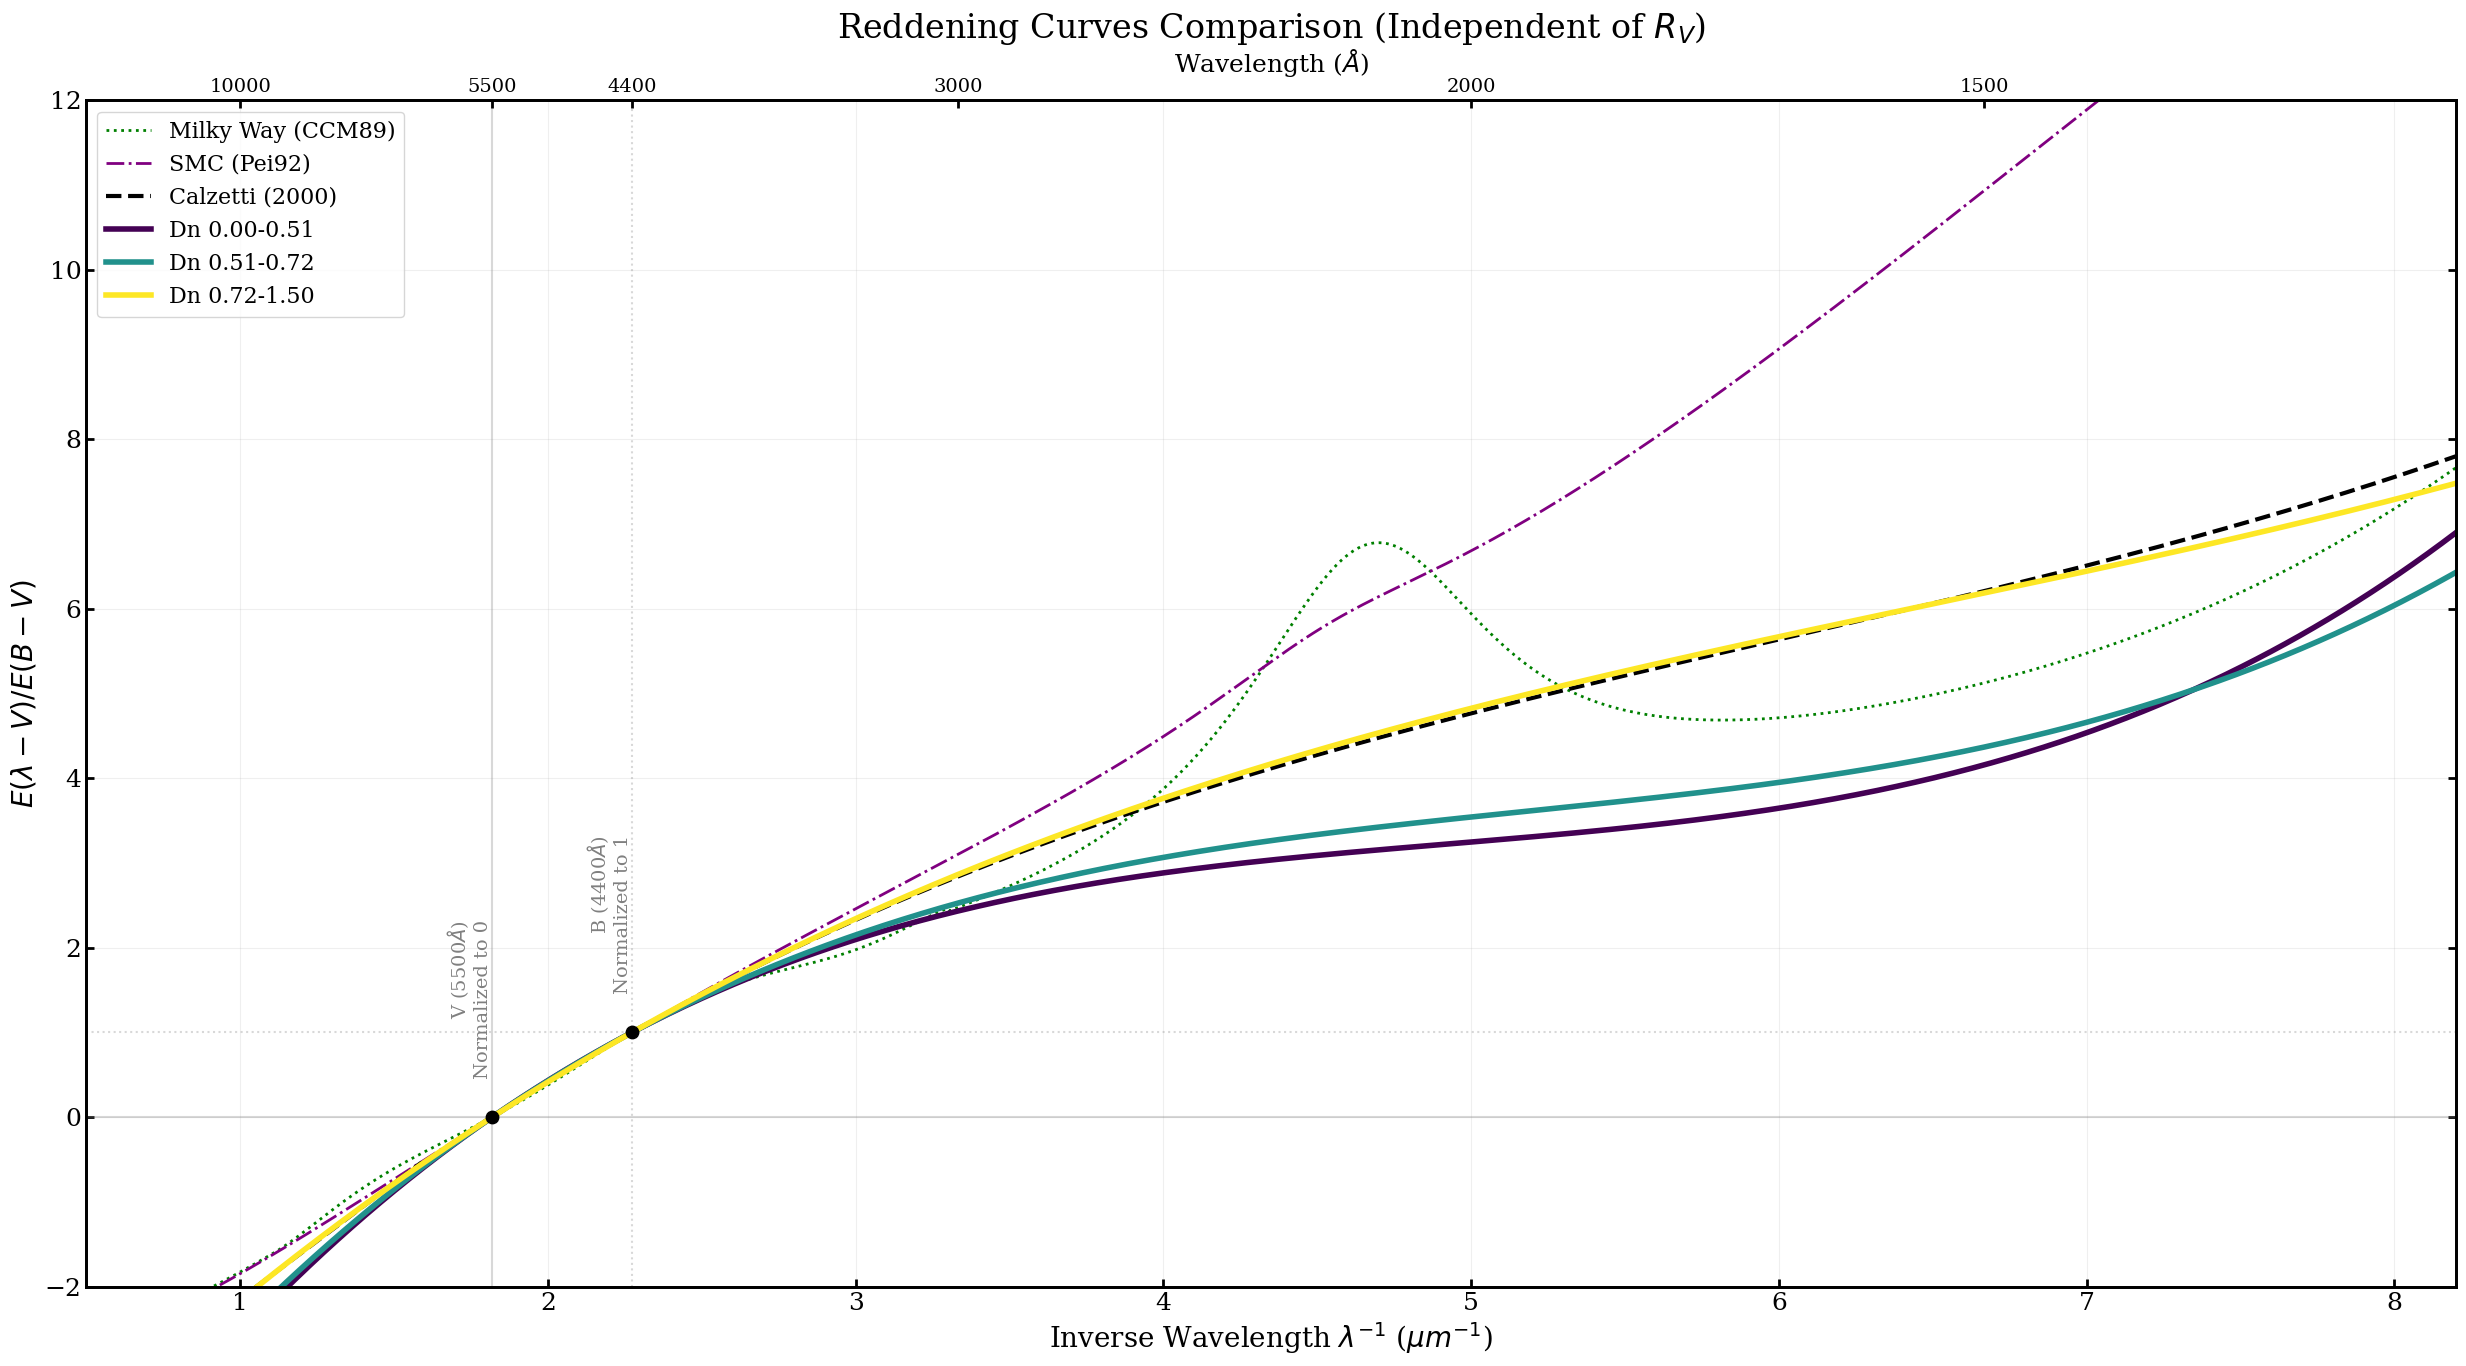

In [24]:
redshift_conditions=np.array([[3,4],[4,5.0],[5.,7.2]])
# redshift_conditions=np.array([[3,3.5],[3.5,4.3],[4.3,5.2],[5.2,5.9],[5.9,7.2]])
def redshift_condition_func(redshift):
    for i, (low, high) in enumerate(redshift_conditions):
        if low < redshift <= high:
            return i
    return -1


analyst_list=   []

for redshift_idx in range(len(redshift_conditions)):
    condition_name = f"Redshift_{redshift_conditions[redshift_idx][0]:.2f}_to_{redshift_conditions[redshift_idx][1]:.2f}"
    analyst = FL.DustAttenuationAnalyst(DJAv4Catalog)


    surveyid_subid_list = []

    for surveyid_subid, entry in DJAv4Catalog.catalog_iterator():
        if not entry['sample_flag']:
            continue



        # 获取 Flux Ratio
        try:
            redshift = entry['determined_redshift']
        except KeyError:
            continue

        # 检查是否属于当前的 Flux Ratio Bin
        if redshift_condition_func(redshift) != redshift_idx:
            continue
        surveyid_subid_list.append(surveyid_subid)

    print(f"Processing Condition: {condition_name}, Total Samples: {len(surveyid_subid_list)}")
    # 3. 载入目标 ID 列表
    analyst.load_and_group_objects(surveyid_subid_list)
    analyst.compute_average_spectra()
    analyst.compute_attenuation_curves(mode='smoothed')
    # 5. 拟合与分析
    analyst.fit_polynomial(order=3)
    # 假设我们想让无穷远处截距匹配 Calzet
    analyst.derive_k_curve_parameters(intercept_val=-0.89877)
    analyst_list.append(analyst)

Processing Condition: Redshift_3.00_to_4.00, Total Samples: 351
Categorizing 351 objects...
Group 0: 31 objects, Mean BD=0.000
Group 1: 48 objects, Mean BD=0.061
Group 2: 61 objects, Mean BD=0.147
Group 3: 49 objects, Mean BD=0.246
Group 4: 30 objects, Mean BD=0.362
Group 5: 20 objects, Mean BD=0.514
Group 6: 12 objects, Mean BD=0.741

Computing average spectra...
Applied masks to 8 regions.
  Group 0: Processed.
Applied masks to 8 regions.
  Group 1: Processed.
Applied masks to 8 regions.
  Group 2: Processed.
Applied masks to 8 regions.
  Group 3: Processed.
Applied masks to 8 regions.
  Group 4: Processed.
Applied masks to 8 regions.
  Group 5: Processed.
Applied masks to 8 regions.
  Group 6: Processed.
Reference spectrum smoothed.
Computed effective curve using smoothed reference.
Polynomial Fit Coefficients (highest power first): [ 0.00948851 -0.19001435  1.46464218 -2.0502024 ]
Derived Parameters: S=2.7265, Intercept=-0.89877, Rv=4.805
Processing Condition: Redshift_4.00_to_5.00

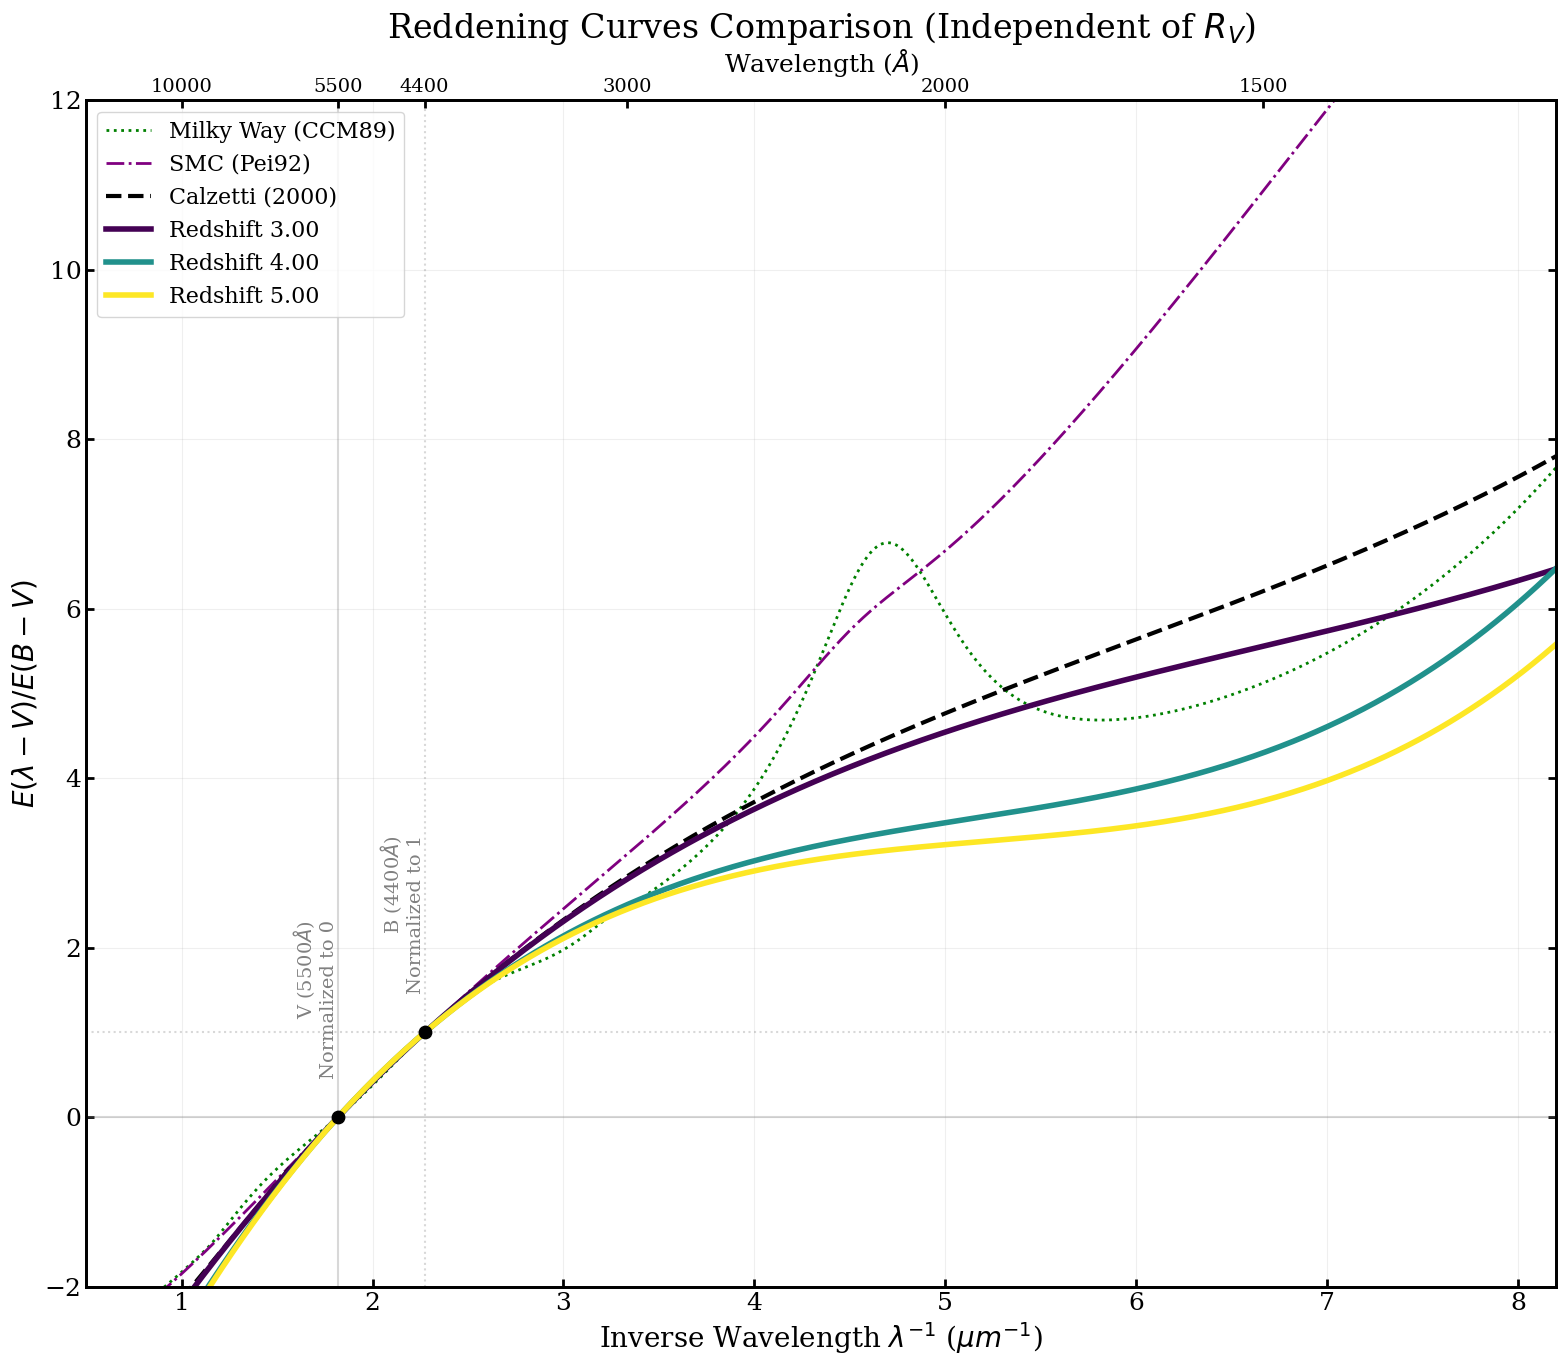

In [25]:

fig, ax = plt.subplots(figsize=(16,14))
if_ref=True
colors_list = plt.cm.viridis(np.linspace(0,1,len(analyst_list)))
for analyst in analyst_list:

    redshift_range = redshift_conditions[analyst_list.index(analyst)]
    condition_name = f"Redshift {redshift_range[0]:.2f}"

    analyst.plot_reddening_curve_comparison(
    if_show=False,
    if_input=True, fig=fig, ax=ax,
    curve_color=colors_list[analyst_list.index(analyst)],
    curve_label=condition_name,
    draw_background=if_ref  # 第一次绘制，需要参考线
)
    if_ref=False  # 之后不需要参考线

In [15]:
has=[]
for surveyid_subid, entry in DJAv4Catalog.catalog_iterator():
    if not entry['sample_flag']:
        continue
    params = entry.get('dust_curve_parameters', {})
    line_params = params.get('Best_Balmer_Decrement_Line_Parameters', {})

    ha = line_params.get('halpha_flux', 0)
    has.append(ha)

(array([343., 330., 146.,  79.,  51.,  33.,  24.,  18.,  10.,  12.]),
 array([0.0e+00, 2.0e-18, 4.0e-18, 6.0e-18, 8.0e-18, 1.0e-17, 1.2e-17,
        1.4e-17, 1.6e-17, 1.8e-17, 2.0e-17]),
 <BarContainer object of 10 artists>)

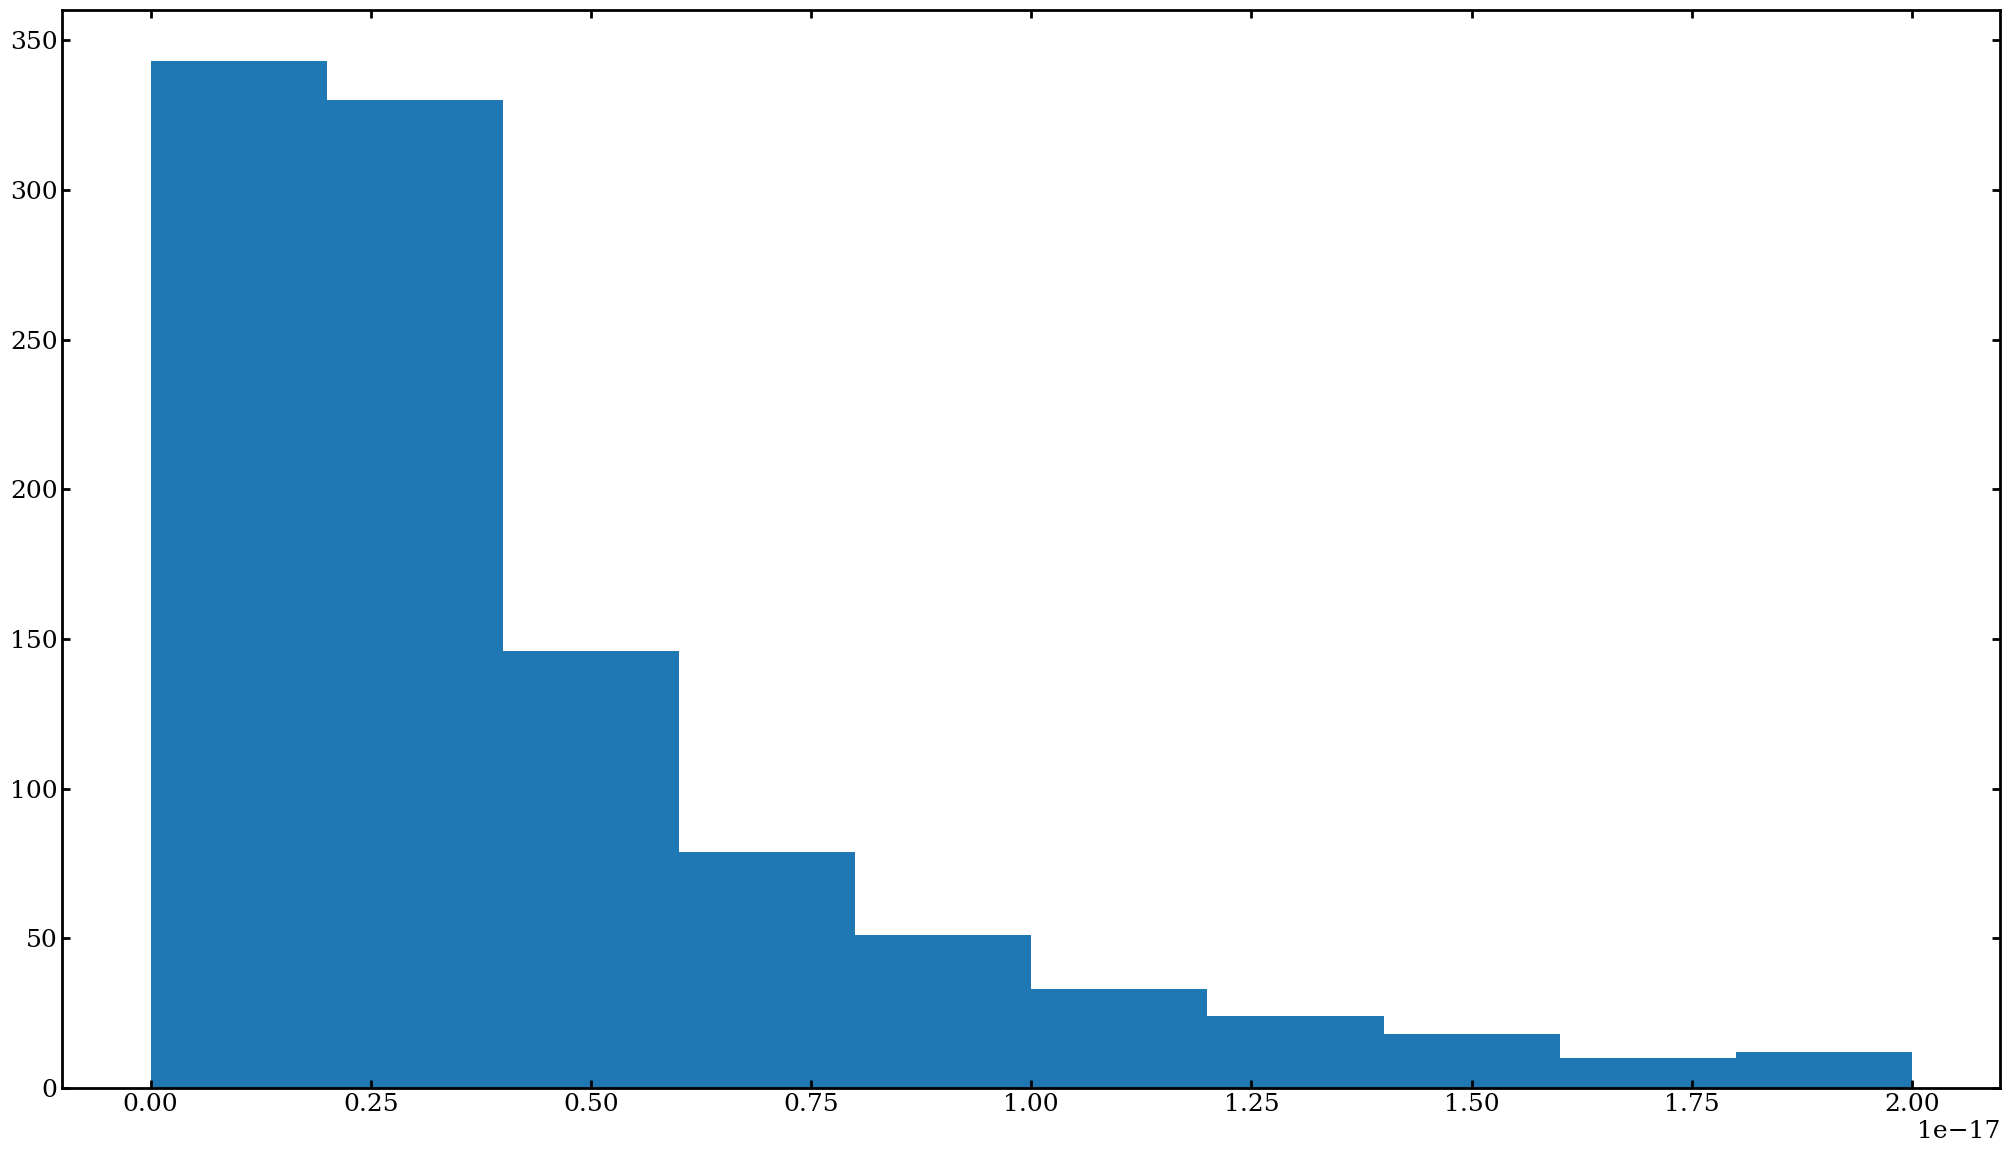

In [19]:
plt.hist(has,range=(0,2e-17))

In [22]:
halpha_flux_threshold = [(0,2e-18),(2e-18,5e-18),(5e-18,5e-17)]
# redshift_conditions=np.array([[3,3.5],[3.5,4.3],[4.3,5.2],[5.2,5.9],[5.9,7.2]])
def halpha_condition_func(halpha_flux):
    for i, (low, high) in enumerate(halpha_flux_threshold):
        if low < halpha_flux <= high:
            return i
    return -1


analyst_list=   []

for halpha_idx in range(len(halpha_flux_threshold)):
    condition_name = f"Halpha_{halpha_flux_threshold[halpha_idx][0]:.2e}_to_{halpha_flux_threshold[halpha_idx][1]:.2e}"
    analyst = FL.DustAttenuationAnalyst(DJAv4Catalog)


    surveyid_subid_list = []

    for surveyid_subid, entry in DJAv4Catalog.catalog_iterator():
        if not entry['sample_flag']:
            continue



        # 获取 Flux Ratio
        try:
            params = entry.get('dust_curve_parameters', {})
            line_params = params.get('Best_Balmer_Decrement_Line_Parameters', {})
            halpha_flux = line_params.get('halpha_flux', 0)
        except KeyError:
            continue

        # 检查是否属于当前的 Flux Ratio Bin
        if halpha_condition_func(halpha_flux) != halpha_idx:
            continue
        surveyid_subid_list.append(surveyid_subid)

    print(f"Processing Condition: {condition_name}, Total Samples: {len(surveyid_subid_list)}")
    # 3. 载入目标 ID 列表
    analyst.load_and_group_objects(surveyid_subid_list)
    analyst.compute_average_spectra()
    analyst.compute_attenuation_curves(mode='smoothed')
    # 5. 拟合与分析
    analyst.fit_polynomial(order=3)
    # 假设我们想让无穷远处截距匹配 Calzet
    analyst.derive_k_curve_parameters(intercept_val=-0.89877)
    analyst_list.append(analyst)

Processing Condition: Halpha_0.00e+00_to_2.00e-18, Total Samples: 343
Categorizing 343 objects...
Group 0: 25 objects, Mean BD=0.000
Group 1: 23 objects, Mean BD=0.066
Group 2: 28 objects, Mean BD=0.144
Group 3: 16 objects, Mean BD=0.240
Group 4: 13 objects, Mean BD=0.356
Group 5: 8 objects, Mean BD=0.523
Group 6: 2 objects, Mean BD=0.734

Computing average spectra...
Applied masks to 8 regions.
  Group 0: Processed.
Applied masks to 8 regions.
  Group 1: Processed.
Applied masks to 8 regions.
  Group 2: Processed.
Applied masks to 8 regions.
  Group 3: Processed.
Applied masks to 8 regions.
  Group 4: Processed.
Applied masks to 8 regions.
  Group 5: Processed.
Applied masks to 8 regions.
  Group 6: Processed.
Reference spectrum smoothed.
Computed effective curve using smoothed reference.
Polynomial Fit Coefficients (highest power first): [ 0.01608472 -0.29893566  1.92672425 -2.64254038]
Derived Parameters: S=2.4268, Intercept=-0.89877, Rv=5.439
Processing Condition: Halpha_2.00e-18_t

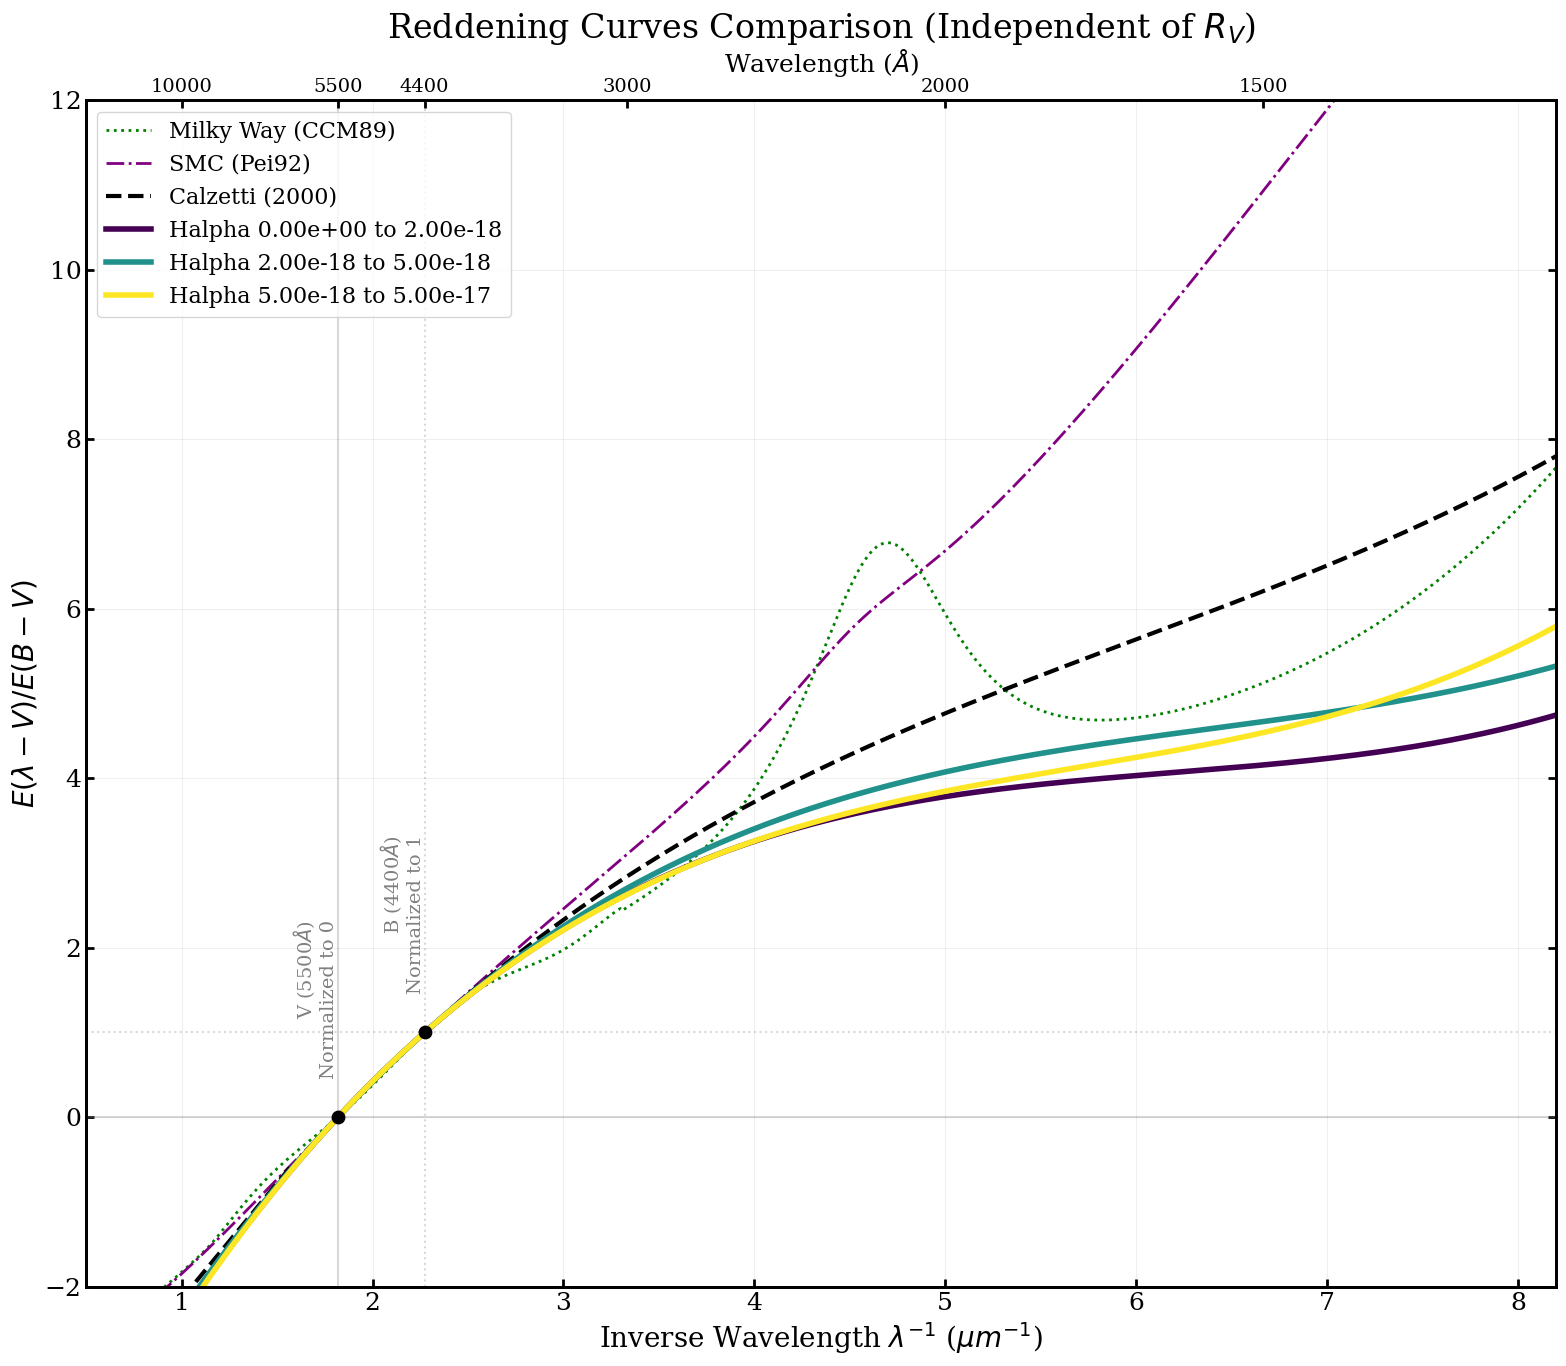

In [23]:

fig, ax = plt.subplots(figsize=(16,14))
if_ref=True
colors_list = plt.cm.viridis(np.linspace(0,1,len(analyst_list)))
for analyst in analyst_list:

    halpha_range = halpha_flux_threshold[analyst_list.index(analyst)]
    condition_name = f"Halpha {halpha_range[0]:.2e} to {halpha_range[1]:.2e}"

    analyst.plot_reddening_curve_comparison(
    if_show=False,
    if_input=True, fig=fig, ax=ax,
    curve_color=colors_list[analyst_list.index(analyst)],
    curve_label=condition_name,
    draw_background=if_ref  # 第一次绘制，需要参考线
)
    if_ref=False  # 之后不需要参考线

Processing Dn Index Range: 0.00 to 0.72
Processing Condition: Redshift_3.00_to_4.00, Total Samples: 177
Categorizing 177 objects...
Group 0: 18 objects, Mean BD=0.000
Group 1: 29 objects, Mean BD=0.064
Group 2: 30 objects, Mean BD=0.148
Group 3: 24 objects, Mean BD=0.247
Group 4: 14 objects, Mean BD=0.356
Group 5: 11 objects, Mean BD=0.516
Group 6: 2 objects, Mean BD=0.796

Computing average spectra...
Applied masks to 8 regions.
  Group 0: Processed.
Applied masks to 8 regions.
  Group 1: Processed.
Applied masks to 8 regions.
  Group 2: Processed.
Applied masks to 8 regions.
  Group 3: Processed.
Applied masks to 8 regions.
  Group 4: Processed.
Applied masks to 8 regions.
  Group 5: Processed.
Applied masks to 8 regions.
  Group 6: Processed.
Reference spectrum smoothed.
Computed effective curve using smoothed reference.
Polynomial Fit Coefficients (highest power first): [ 0.01888475 -0.28633636  1.53708124 -1.94916447]
Derived Parameters: S=3.6441, Intercept=-0.89877, Rv=6.250
Proc

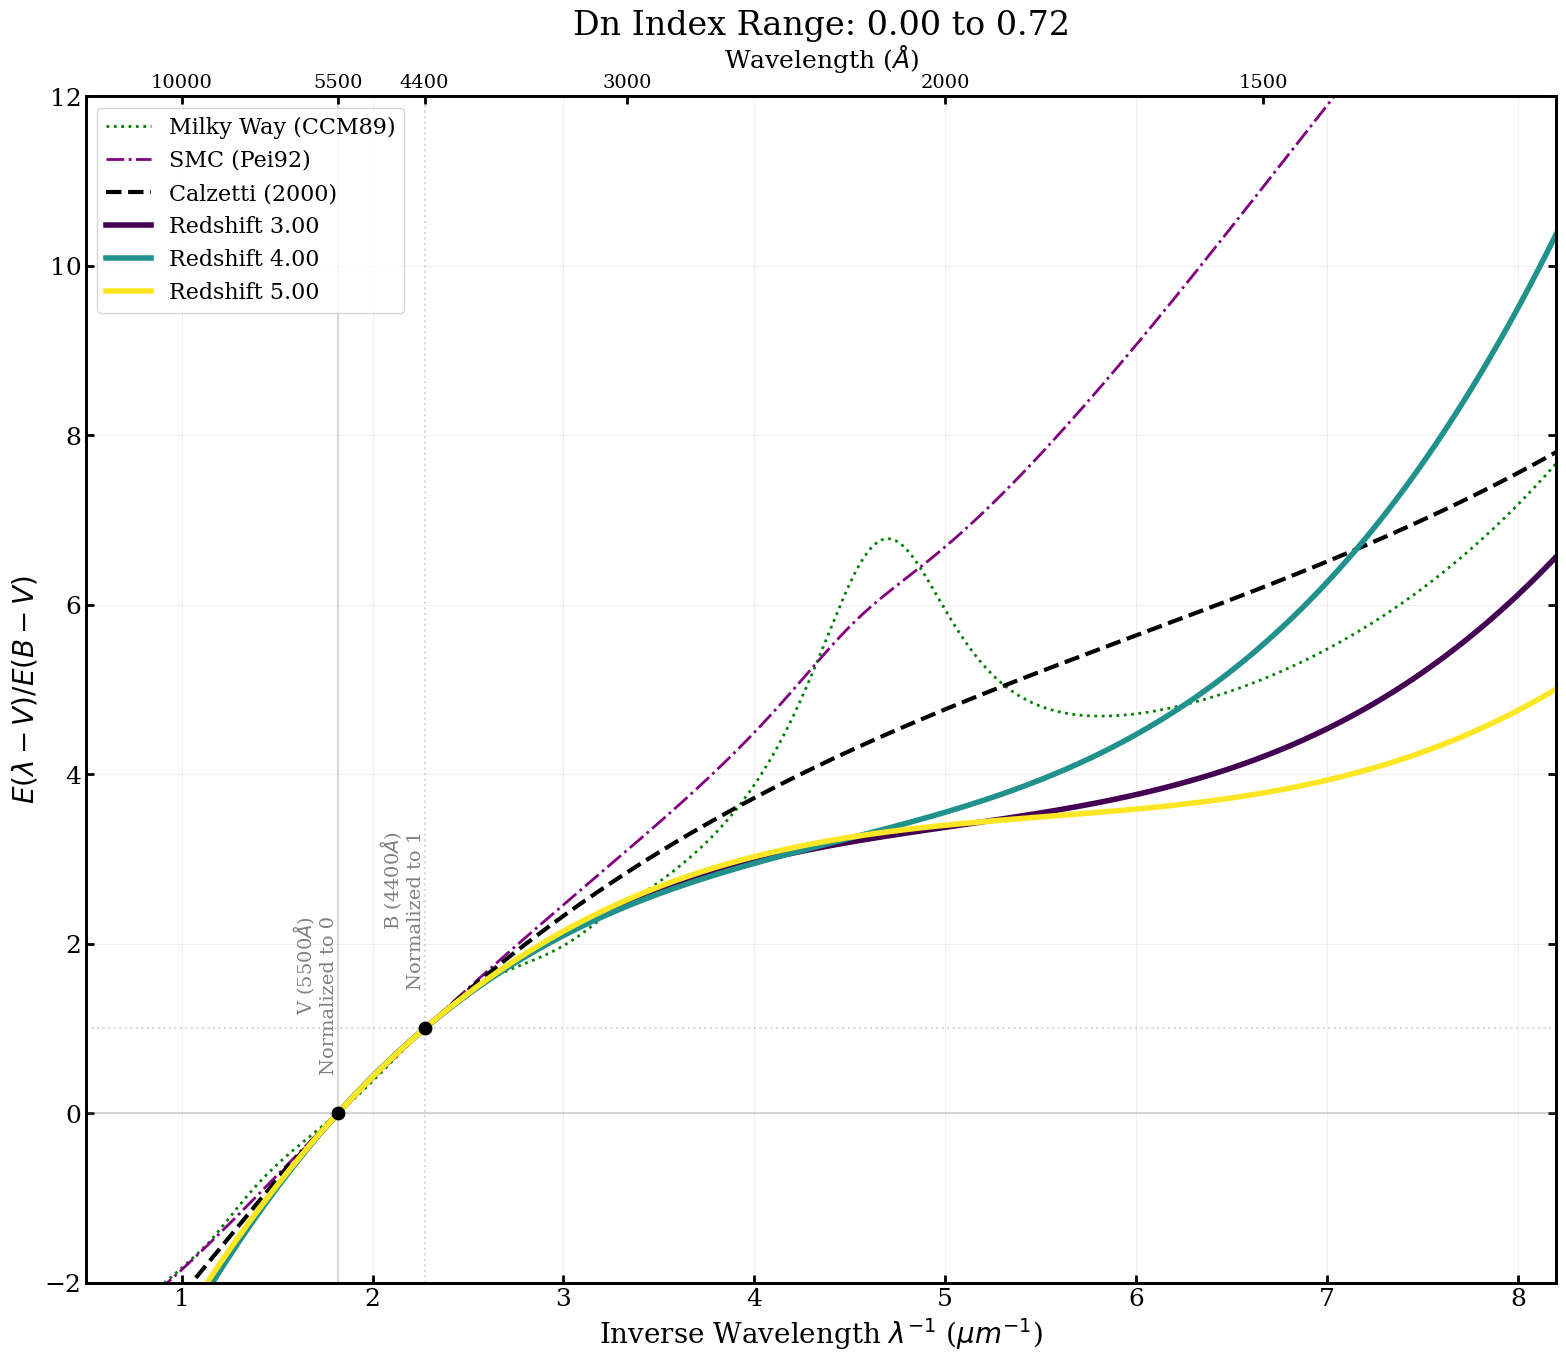

Processing Dn Index Range: 0.72 to 1.50
Processing Condition: Redshift_3.00_to_4.00, Total Samples: 164
Categorizing 164 objects...
Group 0: 12 objects, Mean BD=0.000
Group 1: 19 objects, Mean BD=0.057
Group 2: 28 objects, Mean BD=0.142
Group 3: 25 objects, Mean BD=0.245
Group 4: 15 objects, Mean BD=0.369
Group 5: 9 objects, Mean BD=0.511
Group 6: 10 objects, Mean BD=0.730

Computing average spectra...
Applied masks to 8 regions.
  Group 0: Processed.
Applied masks to 8 regions.
  Group 1: Processed.
Applied masks to 8 regions.
  Group 2: Processed.
Applied masks to 8 regions.
  Group 3: Processed.
Applied masks to 8 regions.
  Group 4: Processed.
Applied masks to 8 regions.
  Group 5: Processed.
Applied masks to 8 regions.
  Group 6: Processed.
Reference spectrum smoothed.
Computed effective curve using smoothed reference.
Polynomial Fit Coefficients (highest power first): [ 0.00320842 -0.09023312  1.04162083 -1.55941765]
Derived Parameters: S=3.0859, Intercept=-0.89877, Rv=4.084
Proc

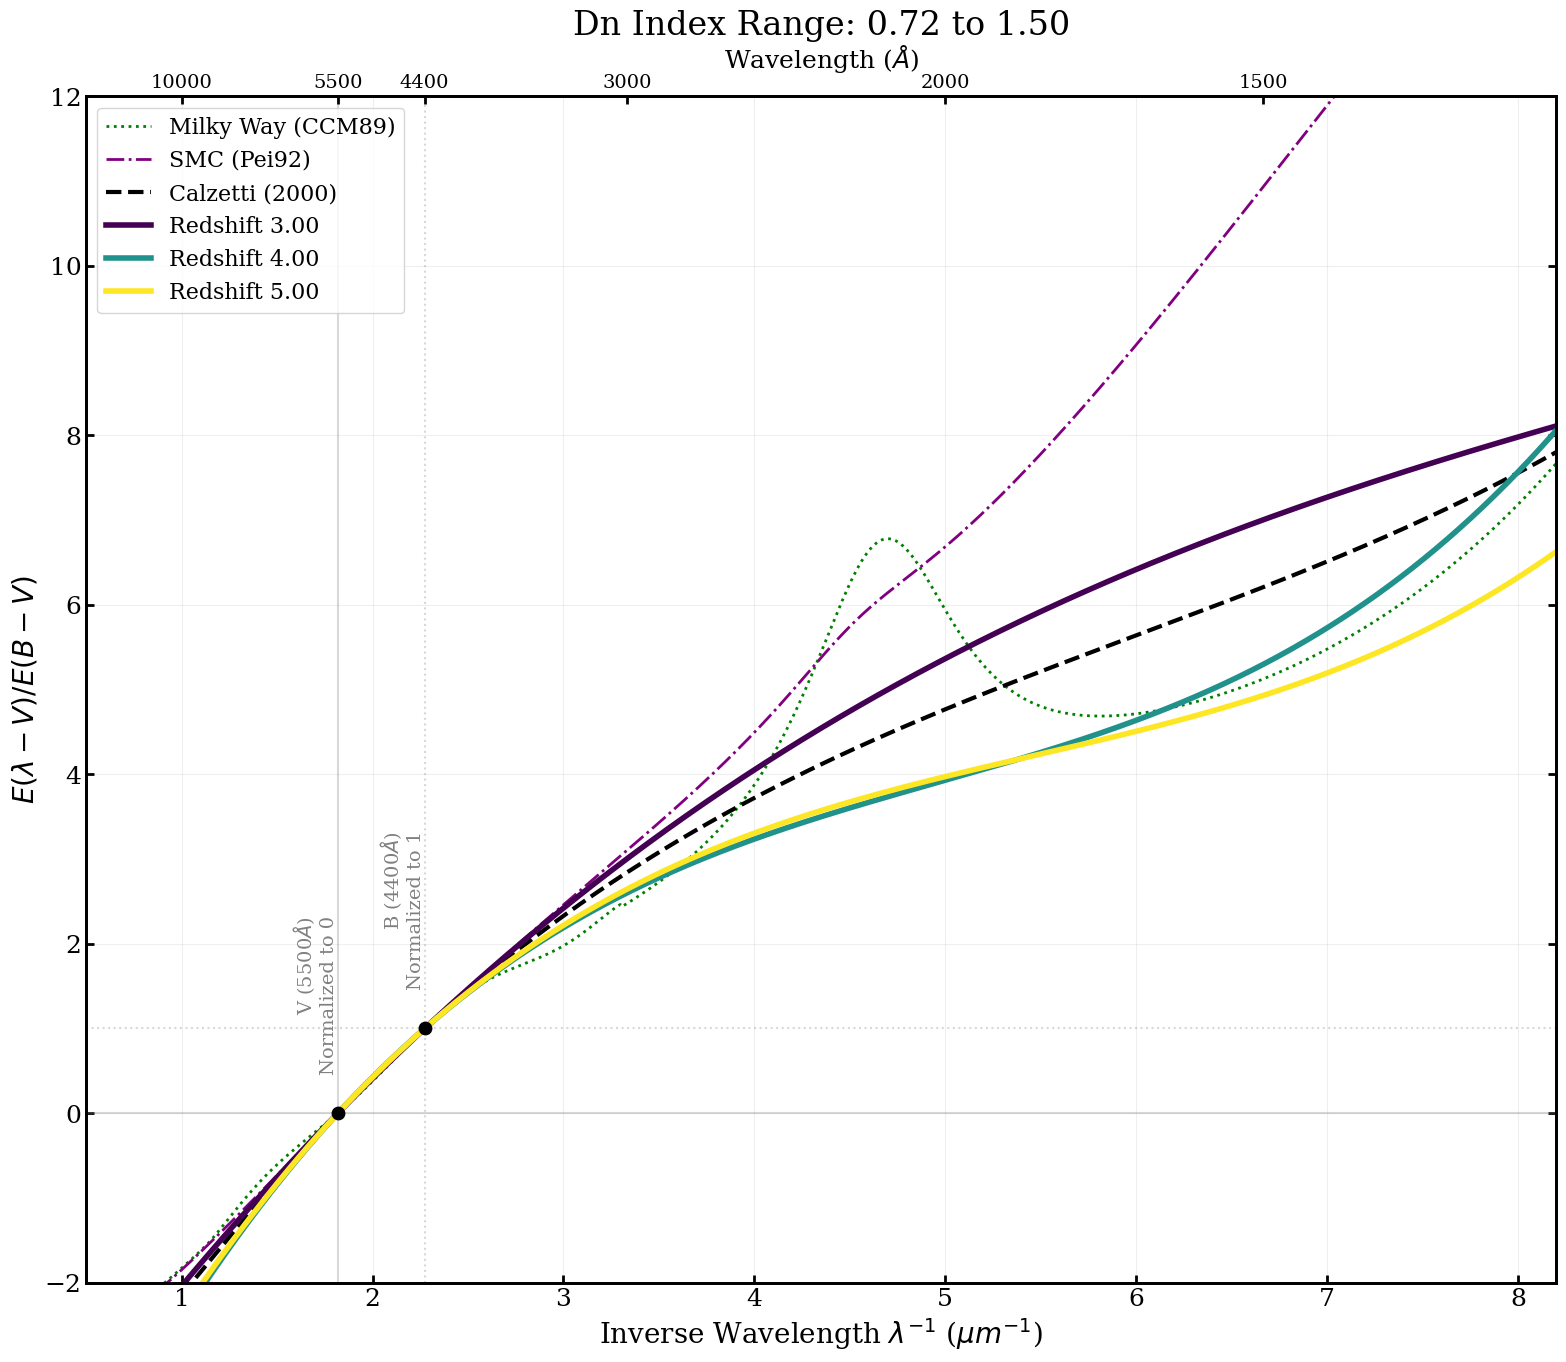

In [5]:
dn_index_conditions = np.array([[0, 0.72], [0.72, 1.5]])
def dn_condition_func(dn_index):
    for i, (low, high) in enumerate(dn_index_conditions):
        if low < dn_index <= high:
            return i
    return -1

redshift_conditions=np.array([[3,4],[4,5.0],[5.,7.2]])
# redshift_conditions=np.array([[3,3.5],[3.5,4.3],[4.3,5.2],[5.2,5.9],[5.9,7.2]])
def redshift_condition_func(redshift):
    for i, (low, high) in enumerate(redshift_conditions):
        if low < redshift <= high:
            return i
    return -1

for dn_idx in range(len(dn_index_conditions)):

    dn_range=dn_index_conditions[dn_idx]
    print(f"Processing Dn Index Range: {dn_range[0]:.2f} to {dn_range[1]:.2f}")

    analyst_list=   []

    for redshift_idx in range(len(redshift_conditions)):
        condition_name = f"Redshift_{redshift_conditions[redshift_idx][0]:.2f}_to_{redshift_conditions[redshift_idx][1]:.2f}"
        analyst = FL.DustAttenuationAnalyst(DJAv4Catalog)


        surveyid_subid_list = []

        for surveyid_subid, entry in DJAv4Catalog.catalog_iterator():
            if not entry['sample_flag']:
                continue

            try:
                measurements = entry['dust_curve_parameters']['Corrected_Flux_Density_Measurements']
                dn_index = measurements['red_flux_density'] / measurements['blue_flux_density']
                if dn_condition_func(dn_index) != dn_idx:
                    continue

            except KeyError:
                continue



            # 获取 Flux Ratio
            try:
                redshift = entry['determined_redshift']
            except KeyError:
                continue

            # 检查是否属于当前的 Flux Ratio Bin
            if redshift_condition_func(redshift) != redshift_idx:
                continue
            surveyid_subid_list.append(surveyid_subid)

        print(f"Processing Condition: {condition_name}, Total Samples: {len(surveyid_subid_list)}")
        # 3. 载入目标 ID 列表
        analyst.load_and_group_objects(surveyid_subid_list)
        analyst.compute_average_spectra()
        analyst.compute_attenuation_curves(mode='smoothed')
        # 5. 拟合与分析
        analyst.fit_polynomial(order=3)
        # 假设我们想让无穷远处截距匹配 Calzet
        analyst.derive_k_curve_parameters(intercept_val=-0.89877)
        analyst_list.append(analyst)


    fig, ax = plt.subplots(figsize=(16,14))
    if_ref=True
    colors_list = plt.cm.viridis(np.linspace(0,1,len(analyst_list)))
    for analyst in analyst_list:

        condition_name = f"Redshift {redshift_conditions[analyst_list.index(analyst)][0]:.2f}"

        analyst.plot_reddening_curve_comparison(
        if_show=False,
        if_input=True, fig=fig, ax=ax,
        curve_color=colors_list[analyst_list.index(analyst)],
        curve_label=condition_name,
        draw_background=if_ref  # 第一次绘制，需要参考线
    )
        if_ref=False  # 之后不需要参考线

    ax.title.set_text(f"Dn Index Range: {dn_range[0]:.2f} to {dn_range[1]:.2f}")

    plt.show()